# 06 — Cross-experiment integration

This notebook is the synthesis chapter of the project. Its goal is not to
recycle earlier figures, but to place posture, paced breathing, breath-hold,
walking, and partial sleep-onset into one coherent physiological story.

The key design decision is to **stop treating LF/HF as the universal summary
axis**. Experiment 4A already showed that slow paced breathing pushes the
respiratory peak into LF, so an integration figure dominated by LF/HF would
contradict the newer evidence. The revised notebook therefore centers the
cross-experiment summary on more robust quantities: mean HR, RMSSD, total
power, and explicitly annotated validity notes.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

def apply_ieee_tbme_style():
    PL.apply_style()
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 10,
        "lines.linewidth": 1.1,
        "axes.linewidth": 0.6,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

def panel_label(ax, text):
    ax.text(
        0.01,
        0.98,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

def save_paper_png(fig, filename):
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")

def short_label(key):
    mapping = {
        "E1PRE": "Pre-sleep supine",
        "E1A": "Supine",
        "E1B": "Sitting",
        "E1C": "Standing",
        "E4A_12pm": "12/min",
        "E4A_9pm": "9/min",
        "E4A_6pm": "6/min",
        "E4A_5pm": "5/min",
        "E4A_3pm": "3/min",
    }
    return mapping.get(key, key)

apply_ieee_tbme_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)

FIG_DIR = REPO_ROOT / "outputs" / "paper_figures_png"
TBL_DIR = REPO_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

FAMILY_COLORS = {
    "posture": "#4c78a8",
    "paced": "#e15759",
    "e2_insp": "#7f3c8d",
    "e2_exp": "#11a579",
    "e3": "#c77c02",
    "sleep": "#2e86ab",
    "quality": "#374151",
}
E4A_COLORS = {
    "E4A_12pm": "#3b4cc0",
    "E4A_9pm": "#7b9ef7",
    "E4A_6pm": "#59a14f",
    "E4A_5pm": "#f28e2b",
    "E4A_3pm": "#e15759",
}
E1_COLORS = {
    "E1PRE": "#2f6690",
    "E1A": "#4c78a8",
    "E1B": "#59a14f",
    "E1C": "#c44e52",
}
print("Setup complete. Integration notebook will emphasize HR, RMSSD, total power, and validity notes.")

Setup complete. Integration notebook will emphasize HR, RMSSD, total power, and validity notes.


## 1. Re-run dispatch across all sessions and save the analysis log

In [2]:
P.ANALYSIS_LOG.drop(P.ANALYSIS_LOG.index, inplace=True)

results = {}
for key in cfg.CONDITION_ORDER:
    results[key] = P.dispatch(key)
for key in ["E2A_insp_1", "E2A_insp_2", "E2B_exp_1", "E2B_exp_2"]:
    if key not in results:
        results[key] = P.dispatch(key)

log_path = TBL_DIR / "analysis_log.csv"
P.save_analysis_log(log_path)
print(f"Wrote {log_path}")

Wrote /Users/wupeien/Developer/hw5_ecg-analysis/outputs/tables/analysis_log.csv


## 2. Build cross-experiment summary data frames

In [3]:
steady_rows = []
for key, r in results.items():
    if cfg.EXPERIMENT_TYPE.get(key) != "steady_state":
        continue
    family = "E1 posture" if key.startswith("E1") else "E4A paced"
    validity = "Standard steady-state HRV"
    if key.startswith("E4A_") and cfg.E4A_EXPECTED_BREATHING_HZ[key] <= 0.15:
        validity = "Slow breathing: LF/HF is band-shifted, use RMSSD / total power"
    steady_rows.append(
        {
            "Family": family,
            "Condition": key,
            "Label": short_label(key),
            "Mean HR (bpm)": r.td_hrv["mean_hr_bpm"],
            "RMSSD (ms)": r.td_hrv["rmssd_ms"],
            "SDNN (ms)": r.td_hrv["sdnn_ms"],
            "Total Power (ms²)": r.fd_hrv["total_power_ms2"],
            "LF/HF": r.fd_hrv["lf_hf_ratio"],
            "Validity note": validity,
        }
    )
steady_df = pd.DataFrame(steady_rows)

e2_rows = []
for condition, keys in {"Inspiratory": ["E2A_insp_1", "E2A_insp_2"], "Expiratory": ["E2B_exp_1", "E2B_exp_2"]}.items():
    for regime in ["pre", "hold", "recovery"]:
        hr_vals = []
        rmssd_vals = []
        for key in keys:
            d = results[key].extras["transient_hrv"][regime]
            hr_vals.append(d["mean_hr_bpm"])
            rmssd_vals.append(d["rmssd_ms"])
        e2_rows.append(
            {
                "Condition": condition,
                "Regime": regime,
                "Mean HR (bpm)": np.mean(hr_vals),
                "HR SD": np.std(hr_vals, ddof=1),
                "RMSSD (ms)": np.mean(rmssd_vals),
                "RMSSD SD": np.std(rmssd_vals, ddof=1),
            }
        )
e2_df = pd.DataFrame(e2_rows)

e3_rows = []
for regime, d in results["E3_walk"].extras["transient_hrv"].items():
    e3_rows.append(
        {
            "Regime": regime,
            "Mean HR (bpm)": d["mean_hr_bpm"],
            "RMSSD (ms)": d["rmssd_ms"],
            "HR slope (bpm/s)": d["hr_slope_bpm_per_s"],
        }
    )
e3_df = pd.DataFrame(e3_rows)

r_e4b = results["E4B_sleep"]
r_e1pre = results["E1PRE"]
t_grid = r_e4b.extras["t_hr_grid"]
hr_smooth = r_e4b.extras["hr_smooth_bpm"]
valid = np.isfinite(hr_smooth) & (hr_smooth > 30)
sleep_start = float(np.nanmean(hr_smooth[(t_grid < 180) & valid]))
sleep_end = float(np.nanmean(hr_smooth[(t_grid > t_grid.max() - 60) & valid]))
sleep_delta = sleep_start - sleep_end
sleep_duration_min = t_grid.max() / 60.0
sleep_anchor = r_e1pre.td_hrv["mean_hr_bpm"]

display(steady_df.round(2))
display(e2_df.round(2))
display(e3_df.round(2))
print(
    f"E4B partial recording: start HR {sleep_start:.1f} bpm, end HR {sleep_end:.1f} bpm, "
    f"delta {sleep_delta:+.1f} bpm over {sleep_duration_min:.1f} min."
)

,Family,Condition,Label,Mean HR (bpm),RMSSD (ms),SDNN (ms),Total Power (ms²),LF/HF,Validity note
0,E4A paced,E4A_3pm,3/min,58.14,55.26,131.38,10493.10,17.47,"Slow breathing: LF/HF is band-shifted, use RMS..."
1,E4A paced,E4A_6pm,6/min,60.15,60.43,91.28,6086.69,11.54,"Slow breathing: LF/HF is band-shifted, use RMS..."
2,E1 posture,E1PRE,Pre-sleep supine,52.96,106.70,93.96,4354.83,0.24,Standard steady-state HRV
3,E1 posture,E1A,Supine,54.02,99.10,81.52,4321.93,0.28,Standard steady-state HRV
4,E1 posture,E1B,Sitting,56.10,61.11,56.61,2016.63,0.54,Standard steady-state HRV
5,E4A paced,E4A_12pm,12/min,59.40,47.74,48.68,1754.32,0.22,Standard steady-state HRV
6,E4A paced,E4A_9pm,9/min,57.02,64.86,77.98,2380.62,0.84,"Slow breathing: LF/HF is band-shifted, use RMS..."
7,E4A paced,E4A_5pm,5/min,59.89,53.93,95.93,8240.47,17.45,"Slow breathing: LF/HF is band-shifted, use RMS..."
8,E1 posture,E1C,Standing,79.68,25.20,41.79,1047.75,1.44,Standard steady-state HRV


,Condition,Regime,Mean HR (bpm),HR SD,RMSSD (ms),RMSSD SD
0,Inspiratory,pre,58.68,4.68,49.37,7.93
1,Inspiratory,hold,70.22,4.65,44.44,8.71
2,Inspiratory,recovery,71.97,10.16,46.10,13.34
3,Expiratory,pre,57.85,0.17,47.10,1.07
4,Expiratory,hold,59.30,2.08,57.24,18.61
5,Expiratory,recovery,58.31,1.32,86.21,15.64


,Regime,Mean HR (bpm),RMSSD (ms),HR slope (bpm/s)
0,seated,60.84,54.40,-0.05
1,walking,83.05,41.06,-0.12
2,recovery,70.28,46.87,-0.13


E4B partial recording: start HR 53.7 bpm, end HR 51.1 bpm, delta +2.6 bpm over 14.3 min.


## 3. Figure 5.1 — Steady-state autonomic operating map

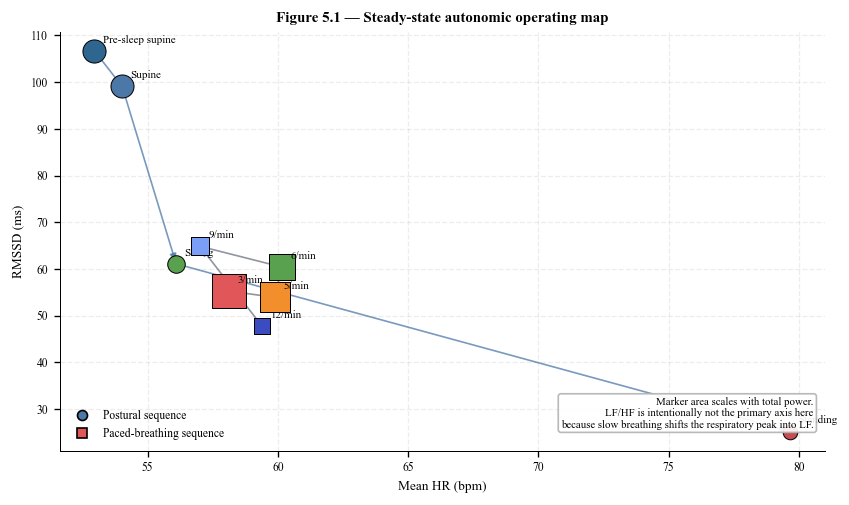

In [4]:
fig, ax = plt.subplots(figsize=(7.16, 4.25))

posture_order = ["E1PRE", "E1A", "E1B", "E1C"]
paced_order = ["E4A_12pm", "E4A_9pm", "E4A_6pm", "E4A_5pm", "E4A_3pm"]

def point_size(tp):
    return 40 + 0.035 * tp

for seq, line_color in [(posture_order, "#4c78a8"), (paced_order, "#6b7280")]:
    for k0, k1 in zip(seq[:-1], seq[1:]):
        a = steady_df.loc[steady_df["Condition"] == k0].iloc[0]
        b = steady_df.loc[steady_df["Condition"] == k1].iloc[0]
        ax.annotate(
            "",
            xy=(b["Mean HR (bpm)"], b["RMSSD (ms)"]),
            xytext=(a["Mean HR (bpm)"], a["RMSSD (ms)"]),
            arrowprops=dict(arrowstyle="-|>", lw=1.0, color=line_color, alpha=0.75),
        )

for _, row in steady_df.iterrows():
    key = row["Condition"]
    if key.startswith("E1"):
        color = E1_COLORS[key]
        marker = "o"
    else:
        color = E4A_COLORS[key]
        marker = "s"
    ax.scatter(
        row["Mean HR (bpm)"],
        row["RMSSD (ms)"],
        s=point_size(row["Total Power (ms²)"]),
        color=color,
        marker=marker,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    ax.annotate(
        row["Label"],
        (row["Mean HR (bpm)"], row["RMSSD (ms)"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=6.7,
    )

ax.set_xlabel("Mean HR (bpm)")
ax.set_ylabel("RMSSD (ms)")
ax.set_title("Figure 5.1 — Steady-state autonomic operating map")
ax.grid(True, linestyle="--", alpha=0.22)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=FAMILY_COLORS["posture"], markeredgecolor="black", label="Postural sequence", markersize=6),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=FAMILY_COLORS["paced"], markeredgecolor="black", label="Paced-breathing sequence", markersize=6),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False)
ax.text(
    0.985,
    0.05,
    "Marker area scales with total power.\nLF/HF is intentionally not the primary axis here\n"
    "because slow breathing shifts the respiratory peak into LF.",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=6.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.92, edgecolor="0.7"),
)

fig.tight_layout()
save_paper_png(fig, "MAIN_19_nb06_integration_operating_map.png")
plt.show()

## 4. Figure 5.2 — Acute challenge and recovery trajectories

/var/folders/qz/c3j7zlrd2qqck8k99q5gp_tw0000gn/T/ipykernel_24526/3681613822.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


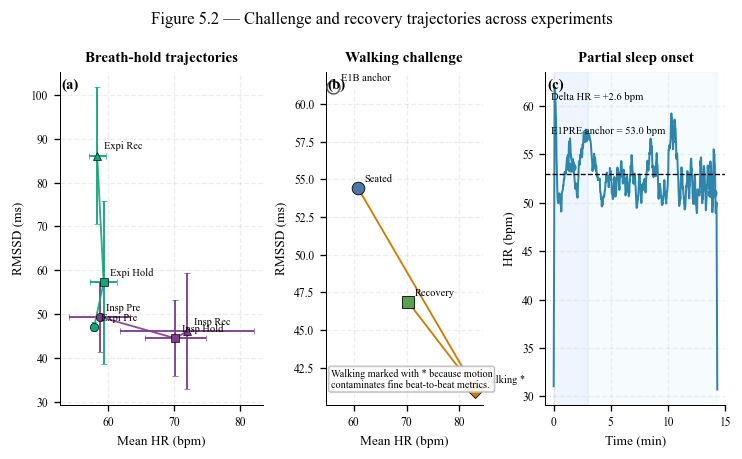

In [5]:
fig = plt.figure(figsize=(7.16, 3.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.0, 1.15], wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

phase_markers = {"pre": "o", "hold": "s", "recovery": "^"}
phase_labels = {"pre": "Pre", "hold": "Hold", "recovery": "Rec"}
cond_colors = {"Inspiratory": FAMILY_COLORS["e2_insp"], "Expiratory": FAMILY_COLORS["e2_exp"]}

for condition in ["Inspiratory", "Expiratory"]:
    sub = e2_df[e2_df["Condition"] == condition].copy()
    sub["order"] = sub["Regime"].map({"pre": 0, "hold": 1, "recovery": 2})
    sub = sub.sort_values("order")
    ax1.plot(sub["Mean HR (bpm)"], sub["RMSSD (ms)"], color=cond_colors[condition], linewidth=1.1, alpha=0.9)
    for _, row in sub.iterrows():
        ax1.errorbar(
            row["Mean HR (bpm)"],
            row["RMSSD (ms)"],
            xerr=row["HR SD"],
            yerr=row["RMSSD SD"],
            fmt=phase_markers[row["Regime"]],
            color=cond_colors[condition],
            markersize=5,
            capsize=2,
            markeredgecolor="black",
            markeredgewidth=0.4,
        )
        ax1.annotate(
            f"{condition[:4]} {phase_labels[row['Regime']]}",
            (row["Mean HR (bpm)"], row["RMSSD (ms)"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=6.2,
        )
panel_label(ax1, "(a)")
ax1.set_title("Breath-hold trajectories")
ax1.set_xlabel("Mean HR (bpm)")
ax1.set_ylabel("RMSSD (ms)")
ax1.grid(True, linestyle="--", alpha=0.22)

e3_anchor = steady_df.loc[steady_df["Condition"] == "E1B"].iloc[0]
ax2.scatter(
    e3_anchor["Mean HR (bpm)"],
    e3_anchor["RMSSD (ms)"],
    s=60,
    facecolor="white",
    edgecolor="0.35",
    linewidth=0.9,
    zorder=3,
)
ax2.annotate("E1B anchor", (e3_anchor["Mean HR (bpm)"], e3_anchor["RMSSD (ms)"]), xytext=(5, 4), textcoords="offset points", fontsize=6.2)

regime_order = ["seated", "walking", "recovery"]
regime_markers = {"seated": "o", "walking": "D", "recovery": "s"}
regime_colors = {"seated": "#4c78a8", "walking": "#c77c02", "recovery": "#59a14f"}
e3_plot = e3_df.set_index("Regime").loc[regime_order]
ax2.plot(e3_plot["Mean HR (bpm)"], e3_plot["RMSSD (ms)"], color=FAMILY_COLORS["e3"], linewidth=1.1)
for regime in regime_order:
    row = e3_plot.loc[regime]
    ax2.scatter(
        row["Mean HR (bpm)"],
        row["RMSSD (ms)"],
        s=58,
        marker=regime_markers[regime],
        color=regime_colors[regime],
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )
    txt = regime.capitalize()
    if regime == "walking":
        txt += " *"
    ax2.annotate(txt, (row["Mean HR (bpm)"], row["RMSSD (ms)"]), xytext=(4, 4), textcoords="offset points", fontsize=6.2)
ax2.text(
    0.03,
    0.05,
    "Walking marked with * because motion\ncontaminates fine beat-to-beat metrics.",
    transform=ax2.transAxes,
    fontsize=6.1,
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9, edgecolor="0.75"),
)
panel_label(ax2, "(b)")
ax2.set_title("Walking challenge")
ax2.set_xlabel("Mean HR (bpm)")
ax2.set_ylabel("RMSSD (ms)")
ax2.grid(True, linestyle="--", alpha=0.22)

t_min = t_grid / 60.0
ax3.plot(t_min, hr_smooth, color=FAMILY_COLORS["sleep"], linewidth=1.2)
ax3.axhline(sleep_anchor, color="black", linestyle="--", linewidth=0.8)
ax3.axvspan(0, 3, color="#dbeafe", alpha=0.45, zorder=-1)
ax3.axvspan(3, t_min.max(), color="#e0f2fe", alpha=0.28, zorder=-2)
ax3.scatter([1.5, t_min.max() - 0.5], [sleep_start, sleep_end], color=FAMILY_COLORS["sleep"], s=26, zorder=4)
ax3.text(0.03, 0.94, f"Delta HR = {sleep_delta:+.1f} bpm", transform=ax3.transAxes, fontsize=6.4, va="top")
ax3.text(0.03, 0.84, f"E1PRE anchor = {sleep_anchor:.1f} bpm", transform=ax3.transAxes, fontsize=6.4, va="top")
panel_label(ax3, "(c)")
ax3.set_title("Partial sleep onset")
ax3.set_xlabel("Time (min)")
ax3.set_ylabel("HR (bpm)")
ax3.grid(True, linestyle="--", alpha=0.18)

fig.suptitle("Figure 5.2 — Challenge and recovery trajectories across experiments", y=1.02)
fig.tight_layout()
save_paper_png(fig, "MAIN_20_nb06_integration_challenge_recovery_atlas.png")
plt.show()

## 5. Figure 5.3 — Pipeline reliability

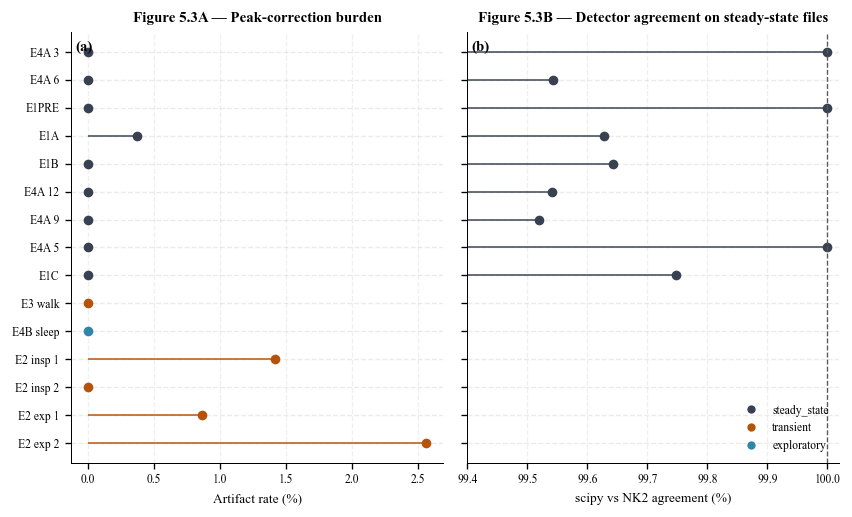

In [6]:
log = P.ANALYSIS_LOG.copy().drop_duplicates(subset=["key"], keep="last")
ordered_keys = [k for k in cfg.CONDITION_ORDER if k in set(log["key"])]
ordered_keys += [k for k in ["E2A_insp_1", "E2A_insp_2", "E2B_exp_1", "E2B_exp_2"] if k in set(log["key"])]
log = log.set_index("key").loc[ordered_keys].reset_index()
log["label"] = log["key"].map({
    "E1PRE": "E1PRE", "E1A": "E1A", "E1B": "E1B", "E1C": "E1C",
    "E4A_12pm": "E4A 12", "E4A_9pm": "E4A 9", "E4A_6pm": "E4A 6", "E4A_5pm": "E4A 5", "E4A_3pm": "E4A 3",
    "E3_walk": "E3 walk", "E4B_sleep": "E4B sleep",
    "E2A_insp_1": "E2 insp 1", "E2A_insp_2": "E2 insp 2", "E2B_exp_1": "E2 exp 1", "E2B_exp_2": "E2 exp 2",
})
log["orchestrator"] = log["orchestrator"].astype(str)
orch_colors = {"steady_state": "#374151", "transient": "#b45309", "exploratory": "#2e86ab"}
y = np.arange(len(log))[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.16, 4.35), sharey=True, gridspec_kw={"width_ratios": [1.0, 1.0]})

for yi, (_, row) in zip(y, log.iterrows()):
    color = orch_colors.get(row["orchestrator"], "#6b7280")
    ax1.hlines(yi, 0, row["artifact_rate_pct"], color=color, linewidth=1.2, alpha=0.75)
    ax1.plot(row["artifact_rate_pct"], yi, "o", color=color, markersize=4.8)
ax1.set_xlabel("Artifact rate (%)")
ax1.set_title("Figure 5.3A — Peak-correction burden")
ax1.set_yticks(y, log["label"])
ax1.grid(axis="x", linestyle="--", alpha=0.2)
panel_label(ax1, "(a)")

steady_log = log[log["n_peaks_agreement_pct"].notna()].copy()
y2 = y[: len(steady_log)]
for yi, (_, row) in zip(y2, steady_log.iterrows()):
    color = orch_colors.get(row["orchestrator"], "#6b7280")
    ax2.hlines(yi, 99.4, row["n_peaks_agreement_pct"], color=color, linewidth=1.2, alpha=0.75)
    ax2.plot(row["n_peaks_agreement_pct"], yi, "o", color=color, markersize=4.8)
ax2.axvline(100.0, color="0.35", linestyle="--", linewidth=0.8)
ax2.set_xlim(99.4, 100.02)
ax2.set_xlabel("scipy vs NK2 agreement (%)")
ax2.set_title("Figure 5.3B — Detector agreement on steady-state files")
ax2.grid(axis="x", linestyle="--", alpha=0.2)
panel_label(ax2, "(b)")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=orch_colors["steady_state"], label="steady_state", markersize=6),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=orch_colors["transient"], label="transient", markersize=6),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=orch_colors["exploratory"], label="exploratory", markersize=6),
]
ax2.legend(handles=legend_handles, loc="lower right", frameon=False)

fig.tight_layout()
save_paper_png(fig, "MAIN_21_nb06_integration_pipeline_reliability.png")
plt.show()

## Appendix A — Partial sleep-onset trajectory

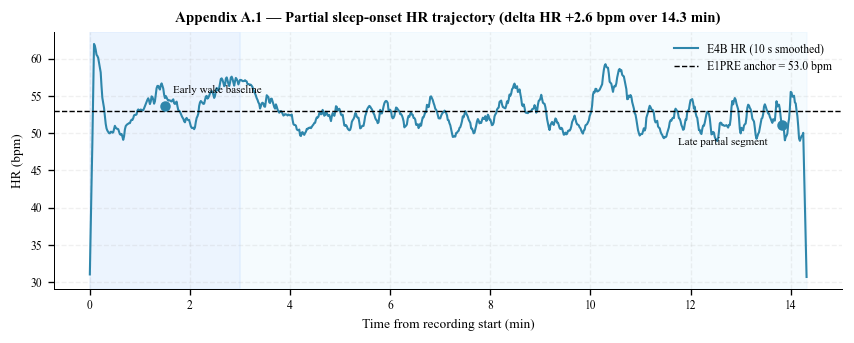

In [7]:
fig, ax = plt.subplots(figsize=(7.16, 2.9))
t_min = t_grid / 60.0
ax.plot(t_min, hr_smooth, color=FAMILY_COLORS["sleep"], linewidth=1.25, label="E4B HR (10 s smoothed)")
ax.axhline(sleep_anchor, color="black", linestyle="--", linewidth=0.85, label=f"E1PRE anchor = {sleep_anchor:.1f} bpm")
ax.axvspan(0, 3, color="#dbeafe", alpha=0.5, zorder=-1)
ax.axvspan(3, t_min.max(), color="#e0f2fe", alpha=0.3, zorder=-2)
ax.scatter([1.5, t_min.max() - 0.5], [sleep_start, sleep_end], color=FAMILY_COLORS["sleep"], s=28, zorder=4)
ax.annotate("Early wake baseline", (1.5, sleep_start), xytext=(5, 8), textcoords="offset points", fontsize=6.7)
ax.annotate("Late partial segment", (t_min.max() - 0.5, sleep_end), xytext=(-62, -12), textcoords="offset points", fontsize=6.7)
ax.set_xlabel("Time from recording start (min)")
ax.set_ylabel("HR (bpm)")
ax.set_title(
    f"Appendix A.1 — Partial sleep-onset HR trajectory (delta HR {sleep_delta:+.1f} bpm over {sleep_duration_min:.1f} min)"
)
ax.legend(loc="upper right", frameon=False)
ax.grid(True, linestyle="--", alpha=0.18)
fig.tight_layout()
save_paper_png(fig, "APP_A03_nb06_partial_sleep_trajectory.png")
plt.show()

## 6. Table 5 — Cross-experiment synthesis

In [8]:
pooled_path = TBL_DIR / "table_2_1b_pooled.csv"
pooled_df = pd.read_csv(pooled_path) if pooled_path.exists() else pd.DataFrame()
e3_path = TBL_DIR / "table_3_1_walking.csv"
e3_tau = np.nan
if e3_path.exists():
    e3_tau = float(pd.read_csv(e3_path).loc[lambda d: d["Segment"] == "recovery", "Recovery τ (s)"].iloc[0])

table_rows = []
for _, row in steady_df.iterrows():
    synthesis = "Baseline vagal state"
    if row["Condition"] == "E1C":
        synthesis = "Orthostatic load: HR up, RMSSD down"
    elif row["Condition"] == "E1B":
        synthesis = "Posture-matched seated anchor"
    elif row["Condition"].startswith("E4A_"):
        synthesis = "Respiratory control expands oscillation amplitude with stable mean HR"
    if row["Condition"] in {"E4A_6pm", "E4A_5pm", "E4A_3pm"}:
        synthesis = "Slow paced breathing: total power rises, LF/HF inflated by band migration"
    table_rows.append(
        {
            "Family": row["Family"],
            "Condition": row["Condition"],
            "Phase": "steady_state",
            "Mean HR (bpm)": row["Mean HR (bpm)"],
            "RMSSD (ms)": row["RMSSD (ms)"],
            "SDNN (ms)": row["SDNN (ms)"],
            "Total Power (ms²)": row["Total Power (ms²)"],
            "LF/HF": row["LF/HF"],
            "Validity note": row["Validity note"],
            "Synthesis note": synthesis,
        }
    )

for _, row in e2_df.iterrows():
    note = "Short segment: no frequency-domain HRV reported"
    synthesis = "Inspiratory hold raises HR strongly" if row["Condition"] == "Inspiratory" and row["Regime"] == "hold" else "Expiratory recovery shows vagal rebound" if row["Condition"] == "Expiratory" and row["Regime"] == "recovery" else "Transient response"
    table_rows.append(
        {
            "Family": "E2 breath-hold",
            "Condition": row["Condition"],
            "Phase": row["Regime"],
            "Mean HR (bpm)": row["Mean HR (bpm)"],
            "RMSSD (ms)": row["RMSSD (ms)"],
            "SDNN (ms)": np.nan,
            "Total Power (ms²)": np.nan,
            "LF/HF": np.nan,
            "Validity note": note,
            "Synthesis note": synthesis,
        }
    )

for _, row in e3_df.iterrows():
    note = "Walking RMSSD is motion-sensitive" if row["Regime"] == "walking" else "Transient seated/walk/recovery segment"
    synthesis = "Exercise tachycardia" if row["Regime"] == "walking" else "Rapid recovery" if row["Regime"] == "recovery" else "Pre-walk seated baseline"
    if row["Regime"] == "recovery" and np.isfinite(e3_tau):
        synthesis += f"; tau = {e3_tau:.1f} s"
    table_rows.append(
        {
            "Family": "E3 walking",
            "Condition": "E3_walk",
            "Phase": row["Regime"],
            "Mean HR (bpm)": row["Mean HR (bpm)"],
            "RMSSD (ms)": row["RMSSD (ms)"],
            "SDNN (ms)": np.nan,
            "Total Power (ms²)": np.nan,
            "LF/HF": np.nan,
            "Validity note": note,
            "Synthesis note": synthesis,
        }
    )

table_rows.append(
    {
        "Family": "E4B sleep",
        "Condition": "E4B_sleep",
        "Phase": "partial_recording",
        "Mean HR (bpm)": np.nanmean(hr_smooth[valid]),
        "RMSSD (ms)": np.nan,
        "SDNN (ms)": np.nan,
        "Total Power (ms²)": np.nan,
        "LF/HF": np.nan,
        "Validity note": "Partial recording: HR trend only",
        "Synthesis note": f"Delta HR {sleep_delta:+.1f} bpm over {sleep_duration_min:.1f} min relative to E1PRE anchor {sleep_anchor:.1f} bpm",
    }
)

df_sum = pd.DataFrame(table_rows)
df_sum.to_csv(TBL_DIR / "table_5_cross_experiment.csv", index=False)
display(df_sum.style.format(precision=2).set_caption("Table 5 — Cross-experiment synthesis"))

if not pooled_df.empty:
    display(pooled_df.style.format(precision=2).set_caption("Reference: pooled E2 frequency-domain comparison from notebook 03"))

,Family,Condition,Phase,Mean HR (bpm),RMSSD (ms),SDNN (ms),Total Power (ms²),LF/HF,Validity note,Synthesis note
0,E4A paced,E4A_3pm,steady_state,58.14,55.26,131.38,10493.10,17.47,"Slow breathing: LF/HF is band-shifted, use RMSSD / total power","Slow paced breathing: total power rises, LF/HF inflated by band migration"
1,E4A paced,E4A_6pm,steady_state,60.15,60.43,91.28,6086.69,11.54,"Slow breathing: LF/HF is band-shifted, use RMSSD / total power","Slow paced breathing: total power rises, LF/HF inflated by band migration"
2,E1 posture,E1PRE,steady_state,52.96,106.70,93.96,4354.83,0.24,Standard steady-state HRV,Baseline vagal state
3,E1 posture,E1A,steady_state,54.02,99.10,81.52,4321.93,0.28,Standard steady-state HRV,Baseline vagal state
4,E1 posture,E1B,steady_state,56.10,61.11,56.61,2016.63,0.54,Standard steady-state HRV,Posture-matched seated anchor
5,E4A paced,E4A_12pm,steady_state,59.40,47.74,48.68,1754.32,0.22,Standard steady-state HRV,Respiratory control expands oscillation amplitude with stable mean HR
6,E4A paced,E4A_9pm,steady_state,57.02,64.86,77.98,2380.62,0.84,"Slow breathing: LF/HF is band-shifted, use RMSSD / total power",Respiratory control expands oscillation amplitude with stable mean HR
7,E4A paced,E4A_5pm,steady_state,59.89,53.93,95.93,8240.47,17.45,"Slow breathing: LF/HF is band-shifted, use RMSSD / total power","Slow paced breathing: total power rises, LF/HF inflated by band migration"
8,E1 posture,E1C,steady_state,79.68,25.20,41.79,1047.75,1.44,Standard steady-state HRV,"Orthostatic load: HR up, RMSSD down"
9,E2 breath-hold,Inspiratory,pre,58.68,49.37,nan,nan,nan,Short segment: no frequency-domain HRV reported,Transient response


,Condition,HF E1B (ms²),HF hold pooled (ms²),HF hold SD (ms²),HF hold ratio (E1B/hold),HF recovery pooled (ms²),HF recovery SD (ms²),HF recovery ratio (rec/E1B)
0,Inspiratory,1123.99,93.96,14.46,11.96,1551.25,582.80,1.38
1,Expiratory,1123.99,391.29,239.12,2.87,1951.58,821.07,1.74


## Synthesis framing

The integration chapter uses two complementary lenses:

1. **Steady-state operating point**: mean HR and RMSSD summarize where the
   cardiovascular system settles when posture or respiration is held constant.
2. **Challenge / recovery trajectory**: transient experiments are better
   understood as paths through state space rather than as single HRV numbers.

This framing avoids a common mistake: forcing every experiment into the same
frequency-domain summary even when the underlying assumptions are violated.

## Integrated results

**Posture and paced breathing moved the autonomic system in qualitatively
different ways.** In the postural sequence, mean HR increased from roughly
`53.0` to `79.7 bpm`
while RMSSD fell from about `106.7` to
`25.2 ms`, which is the expected
orthostatic pattern. By contrast, paced breathing kept mean HR in a narrow
band (`57.0`–`60.1 bpm`)
while SDNN expanded from `48.7` to
`131.4 ms` and total power increased by about
`6.0x`. This is exactly why Figure 5.1 uses
HR-RMSSD space and marker size instead of collapsing everything into LF/HF.

**Breath-hold and walking behaved like challenge-response systems, not
steady-state operating points.** Inspiratory hold raised mean HR from
`58.7` to `70.2 bpm`, whereas expiratory hold
produced a much smaller chronotropic shift but a large recovery-time RMSSD
rebound to `86.2 ms`. The pooled frequency-domain comparison
from notebook 03 supports the same story: inspiratory hold suppressed HF by
about `12.0x` relative to the seated E1B anchor, while
expiratory recovery rebounded to roughly `1.74x` of baseline.
Walking, in turn, pushed mean HR to `83.0 bpm` and reduced RMSSD
to `41.1 ms`, followed by a rapid recovery with a fitted tau
of `6.8 s`.

**The partial sleep recording behaves like a weak but directionally plausible
transition, not a main experiment.** The E4B trace showed a smoothed HR drop
of `2.6 bpm` across `14.3 min`,
ending close to the E1PRE pre-sleep supine anchor. That is compatible with an
early wake-to-sleep transition, but the dataset is too short and incomplete to
carry inferential weight. It is kept as appendix evidence only.

**Pipeline reliability remained strong after integration.** The steady-state
files stayed near perfect detector agreement, and artifact / correction rates
were low across the board. The main analytic caveats are therefore
physiological and design-driven, not software-driven: band migration during
slow breathing, motion contamination during walking, and incomplete duration
for the sleep recording.

## Discussion

The integrated picture is cleaner once the experiments are allowed to answer
different physiological questions. Experiment 1 primarily maps **postural
autonomic set-point shifts**. Experiment 4A maps **respiratory entrainment and
oscillation amplitude control**. Experiment 2 shows **acute respiratory
perturbation and rebound**, while Experiment 3 shows **exercise load and rapid
recovery kinetics**. The sleep appendix then acts as a weak ecological check:
HR drifts in the expected direction, but the recording is incomplete.

This division of labor also explains why LF/HF cannot remain the global thesis
metric. It works tolerably for ordinary steady-state posture comparisons, but
it becomes misleading once respiration is intentionally slowed below the HF
boundary. The revised notebook therefore makes a methodological argument in
addition to a physiological one: cross-experiment synthesis should privilege
metrics whose assumptions remain valid across manipulations, and should mark
validity limits explicitly rather than bury them in footnotes.

The main remaining limitations are experimental rather than computational.
Paced breathing was not randomized, so order and training effects may still
contribute to the monotonic SDNN increase. The walking segment is short and
motion-contaminated. The sleep recording is partial. None of these caveats
invalidate the central thesis, but they do shape how strongly each experiment
should be weighted in the final narrative.